# Plots

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
SWEEP_PATH = Path('sweep_summary.json')
UNION42_PATH = Path('swe_bench_eval_union42.json')

with SWEEP_PATH.open() as f:
    sweep = json.load(f)['runs']

with UNION42_PATH.open() as f:
    union42 = set(json.load(f)['instance_ids'])
N_UNION = len(union42)

to_keep = [
    'Run 3 (s20_e3)',
    'Run 2 (s70_e3)',
    'Run 1 (s200_e3)'
]
sweep = {k: v for k, v in sweep.items() if k in to_keep}

# number of steps vs pass@1
sweep_scores = {}
x = []
y = []
for name, r in sweep.items():
    cfg = r['config']
    sweep_scores[name] = r['pass1_mean'] / 446 * 100
    x.append(r['config']['max_steps'])
    y.append(r['pass1_mean'] / 446 * 100)


In [3]:
# 5x eval of talkie-1930 ckpt-2000 (full 100k dataset, 2016 steps)
FULLRUN_RUNS = [
    Path(f'talkie-1930-v2-lr2e5-ckpt2000-pass5-run{i}.json')
    for i in range(1, 6)
]

FULLRUN_N_INSTANCES = 446
FULLRUN_N_UNIQUE_EXAMPLES = 100_000

fullrun = []
for p in FULLRUN_RUNS:
    with p.open() as f:
        d = json.load(f)
    resolved = set(d['resolved_ids'])
    fullrun.append({
        'resolved': resolved,
        'resolved_446': len(resolved),
        'resolved_in_union42': len(resolved & union42),
    })

fullrun_pass1_446 = np.mean([r['resolved_446'] for r in fullrun]) / FULLRUN_N_INSTANCES * 100
fullrun_pass1_union = np.mean([r['resolved_in_union42'] for r in fullrun]) / N_UNION * 100
print(f"full-run ckpt-2000 pass@1 (446 set): {fullrun_pass1_446:.2f}%")
print(f"full-run ckpt-2000 pass@1 (union42): {fullrun_pass1_union:.2f}%   (apples-to-apples with #6 sweep)")
x.append(2000)
y.append(fullrun_pass1_446)


full-run ckpt-2000 pass@1 (446 set): 4.48%
full-run ckpt-2000 pass@1 (union42): 41.90%   (apples-to-apples with #6 sweep)


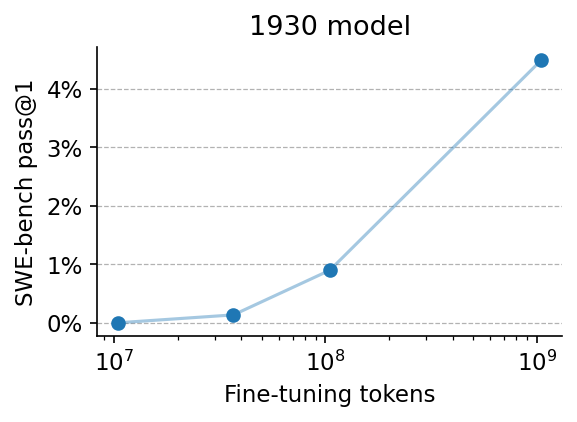

In [4]:
fig = plt.figure(figsize=(4, 2.5), dpi=150)
ax = fig.add_subplot(111)  # or fig.add_subplot(1, 1, 1)
from matplotlib.ticker import FuncFormatter
colors = sb.color_palette()
plt.plot(np.array(x)*65536*8, y, 'o')
plt.plot(np.array(x)*65536*8, y, color=colors[0], alpha=0.4)
plt.xscale('log')
plt.xlabel('Fine-tuning tokens', fontsize=11)
plt.ylabel('SWE-bench pass@1', fontsize=11)
plt.grid(axis='y', alpha=0.6, linewidth=0.6, linestyle="--", color="gray", zorder=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0f}%"))
plt.title('1930 model', fontsize=13)
plt.savefig('plots/scaling.png', bbox_inches='tight')

In [5]:
def load_graded_runs(name_glob):
    """Return list of resolved_count per pass-eval run; empty if none on disk."""
    runs = []
    for p in sorted(Path('.').glob(name_glob)):
        with p.open() as f:
            d = json.load(f)
        runs.append(len(d.get('resolved_ids', [])))
    return runs

talkie_1930_resolved = [r['resolved_446'] for r in fullrun]
talkie_web_resolved = load_graded_runs(
    'talkie-web-v2-lr2e5-ckpt2000-pass3-run*.json'
)

WEB_SINGLE_ATTEMPT_FALLBACK = (13, 446)  # from issue #3 (web-v2 ckpt-2000, single attempt)

if talkie_web_resolved:
    n_web = len(talkie_web_resolved)
    web_pass1 = np.mean(talkie_web_resolved) / 446 * 100
    web_err = np.std(talkie_web_resolved, ddof=1) / 446 * 100 if n_web > 1 else 0.0
    web_pending = False
else:
    n_web = 0
    web_pass1 = WEB_SINGLE_ATTEMPT_FALLBACK[0] / WEB_SINGLE_ATTEMPT_FALLBACK[1] * 100
    web_err = 0.0
    web_pending = True

n_1930 = len(talkie_1930_resolved)
talkie_1930_pass1 = np.mean(talkie_1930_resolved) / 446 * 100
talkie_1930_err = np.std(talkie_1930_resolved, ddof=1) / 446 * 100

print(f"1930  ckpt-2000 (n={n_1930}): {talkie_1930_pass1:.2f}% ± {talkie_1930_err:.2f}pp  (per-run: {talkie_1930_resolved})")
if web_pending:
    print(f"web   ckpt-2000        : {web_pass1:.2f}%   (pending eval - using single-attempt #3 fallback)")
else:
    print(f"web   ckpt-2000 (n={n_web}): {web_pass1:.2f}% ± {web_err:.2f}pp  (per-run: {talkie_web_resolved})")


1930  ckpt-2000 (n=5): 4.48% ± 0.69pp  (per-run: [23, 18, 20, 23, 16])
web   ckpt-2000 (n=3): 5.75% ± 1.04pp  (per-run: [31, 23, 23])


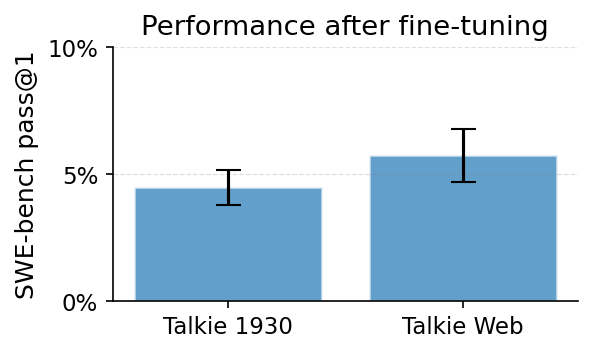

In [6]:
fig, ax = plt.subplots(figsize=(4, 2.2), dpi=150)

labels = [f'Talkie 1930',
          f'Talkie Web']
values = [talkie_1930_pass1, web_pass1]
errs = [talkie_1930_err, web_err]

colors = sb.color_palette()
colors = [colors[0], colors[0]]

plt.grid(axis='y', alpha=0.25, linewidth=0.6, linestyle="--", color="gray", zorder=0)
plt.ylim(None, 10)
plt.yticks([0, 5, 10])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:.0f}%"))

bars = ax.bar(labels, values, yerr=errs, capsize=6, color=colors,
              edgecolor='white', linewidth=1.2, alpha=0.7)
plt.ylabel('SWE-bench pass@1', fontsize=12)
plt.title('Performance after fine-tuning')
plt.savefig('plots/web1930.png', bbox_inches='tight')